In [1]:
import sys
import types
from pathlib import Path

pkg = types.ModuleType("pkg_resources")

def resource_string(package, resource):
    import importlib
    mod = importlib.import_module(package)
    mod_path = Path(mod.__file__).parent
    return (mod_path / resource).read_bytes()

pkg.resource_string = resource_string
sys.modules["pkg_resources"] = pkg

import earthpy as et

In [2]:
import os
import earthpy as et
# Downloads sample data to your local earth-analytics directory
data_dir = et.data.get_data("vignette-elevation")
# The example DEM file (pre_DTM.tif) lives inside that folder
dem_path = os.path.join(data_dir, "pre_DTM.tif")
print(dem_path)

/Users/jayantabiswas/earth-analytics/data/vignette-elevation/./pre_DTM.tif


In [3]:
import elevation
import os

os.makedirs("data/raw", exist_ok=True)

bounds = (-82.59, 35.36, -82.56, 35.43)
out_dem = os.path.abspath("data/raw/srtm_clip.tif")  # absolute path
elevation.clip(bounds=bounds, output=out_dem, product="SRTM1")
print("Wrote:", out_dem)

make: Nothing to be done for `download'.
make: Nothing to be done for `all'.
cp SRTM1.vrt SRTM1.01fd017c8f86480883ff8df87d3db2b9.vrt
gdal_translate -q -co TILED=YES -co COMPRESS=DEFLATE -co ZLEVEL=9 -co PREDICTOR=2 -projwin -82.59 35.43 -82.56 35.36 SRTM1.01fd017c8f86480883ff8df87d3db2b9.vrt /Users/jayantabiswas/geovis_labs/lab6/data/raw/srtm_clip.tif
rm -f SRTM1.01fd017c8f86480883ff8df87d3db2b9.vrt
Wrote: /Users/jayantabiswas/geovis_labs/lab6/data/raw/srtm_clip.tif


In [4]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import rasterio as rio
import earthpy as et
import earthpy.plot as ep
import earthpy.spatial as es
import importlib.metadata
print("earthpy:", importlib.metadata.version("earthpy"))
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("rasterio:", rio.__version__)
# Optional (recommended)
try:
    import richdem as rd
    print("richdem:", rd.__version__)
except Exception as e:
    print("richdem: NOT INSTALLED (ok) ->", e)

earthpy: 0.9.4
numpy: 2.4.2
matplotlib: 3.10.8
rasterio: 1.4.4
richdem: NOT INSTALLED (ok) -> module 'richdem' has no attribute '__version__'


In [5]:
DEM_PATH = "data/raw/srtm_clip.tif" # <-- change (or set from Option B/C)
with rio.open(DEM_PATH) as src:
    dem = src.read(1).astype("float32")
    profile = src.profile
    crs = src.crs
    transform = src.transform
    nodata = src.nodata
print("CRS:", crs)
print("Shape (rows, cols):", dem.shape)
print("Resolution:", (transform.a, -transform.e))
print("Nodata:", nodata)
# Mask nodata (and any other invalid values you decide)
if nodata is not None:
    dem[dem == nodata] = np.nan
print("Min/Max (masked):", np.nanmin(dem), np.nanmax(dem))

CRS: EPSG:4326
Shape (rows, cols): (253, 109)
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Nodata: -32768.0
Min/Max (masked): 622.0 840.0


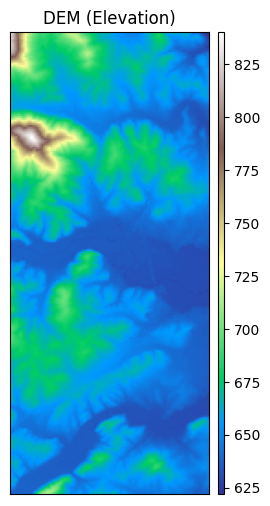

In [6]:
# Simple DEM plot (EarthPy helper)
ep.plot_bands(
        dem,
        cmap="terrain", # try: "gist_earth", "viridis", "cividis", "terrain"
        title="DEM (Elevation)",
        figsize=(10, 6),
)
plt.show()

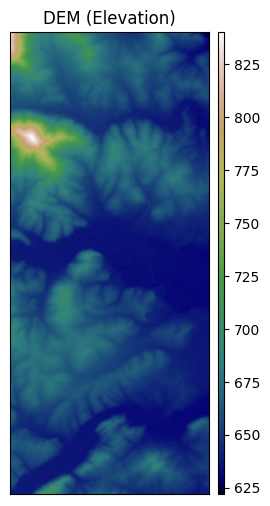

In [7]:
# Simple DEM plot (EarthPy helper)
ep.plot_bands(
        dem,
        cmap="gist_earth", # try: "gist_earth", "viridis", "cividis", "terrain"
        title="DEM (Elevation)",
        figsize=(10, 6),
)
plt.show()

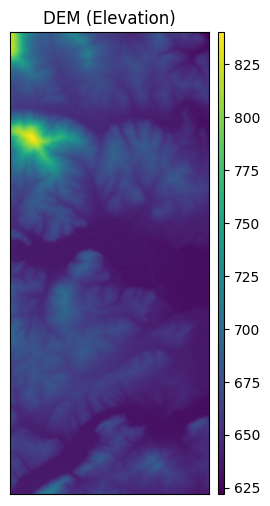

In [8]:
# Simple DEM plot (EarthPy helper)
ep.plot_bands(
        dem,
        cmap="viridis", # try: "gist_earth", "viridis", "cividis", "terrain"
        title="DEM (Elevation)",
        figsize=(10, 6),
)
plt.show()

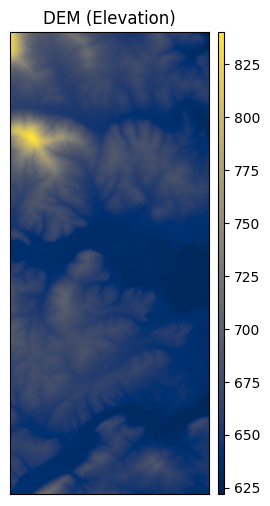

In [9]:
# Simple DEM plot (EarthPy helper)
ep.plot_bands(
        dem,
        cmap="cividis", # try: "gist_earth", "viridis", "cividis", "terrain"
        title="DEM (Elevation)",
        figsize=(10, 6),
)
plt.show()

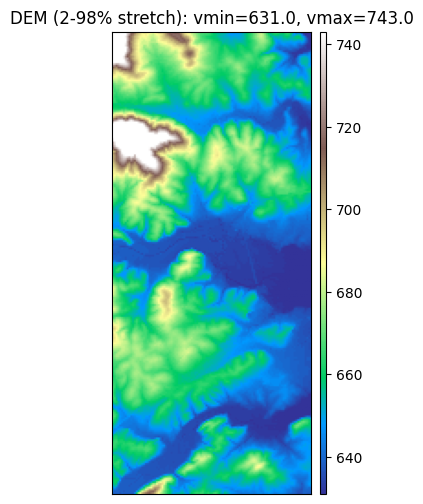

In [10]:
# Percentile stretch (2nd-98th is a common starting point)
vmin, vmax = np.nanpercentile(dem, (2, 98))
ep.plot_bands(
        dem,
        cmap="terrain",
        vmin=vmin,
        vmax=vmax,
        title=f"DEM (2-98% stretch): vmin={vmin:.1f}, vmax={vmax:.1f}",
        figsize=(10, 6),
)
plt.show()

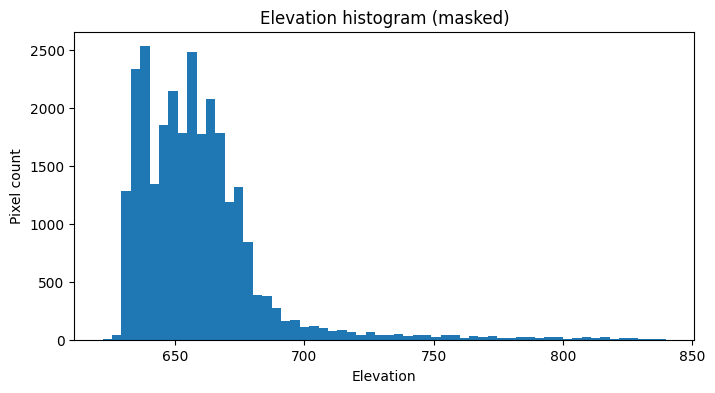

In [12]:
vals = dem[np.isfinite(dem)]
plt.figure(figsize=(8, 4))
plt.hist(vals, bins=60)
plt.title("Elevation histogram (masked)")
plt.xlabel("Elevation")
plt.ylabel("Pixel count")
plt.show()

In [13]:
import richdem as rd
# Load DEM with georeferencing (best practice)
# dem_rd = rd.LoadGDAL(DEM_PATH) this one is not working for some reason
dem_rd = rd.rdarray(dem, no_data= nodata)
# Slope options:
# - 'slope_degrees' (0-90) is easy to interpret
# - 'slope_riserun' (rise/run) can be converted to percent slope
slope_deg = rd.TerrainAttribute(dem_rd, attrib="slope_degrees")
# Aspect is a circular direction (0-360 degrees, often 0/360 = North)
aspect = rd.TerrainAttribute(dem_rd, attrib="aspect")

Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)



A Slope calculation (degrees)
C Horn, B.K.P., 1981. Hill shading and the reflectance map. Proceedings of the IEEE 69, 14–47. doi:10.1109/PROC.1981.11918

t Wall-time = 0.00109458===================== ] (99% - 0.0s - 1 threads)

A Aspect attribute calculation
C Horn, B.K.P., 1981. Hill shading and the reflectance map. Proceedings of the IEEE 69, 14–47. doi:10.1109/PROC.1981.11918

t Wall-time = 0.00166792===================== ] (99% - 0.0s - 1 threads)


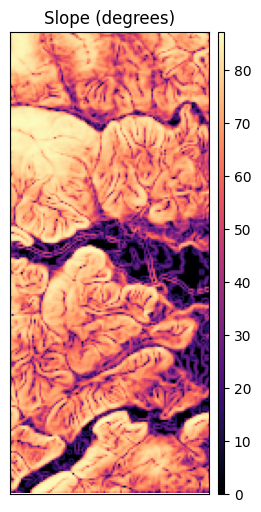

In [14]:
# Slope
ep.plot_bands(
        np.array(slope_deg),
        cmap="magma",
        title="Slope (degrees)",
        figsize=(10, 6),
)
plt.show()


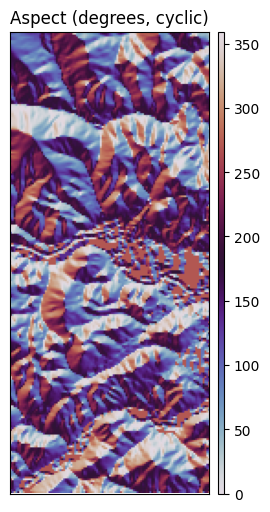

In [15]:
# Aspect (use a cyclic colormap if available)
ep.plot_bands(
        np.array(aspect),
        cmap="twilight", # try: "hsv" if twilight is not available
        title="Aspect (degrees, cyclic)",
        figsize=(10, 6),
)
plt.show()

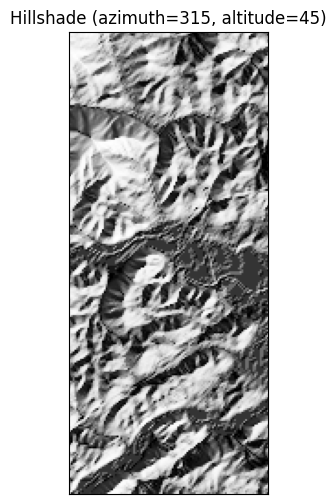

In [16]:
# EarthPy hillshade from the DEM array
# azimuth: 0=N, 90=E, 180=S, 270=W (default often ~315)
# altitude: 0-90 (higher = less shadow)
azimuth = 315
altitude = 45
hill = es.hillshade(dem, azimuth=azimuth, altitude=altitude)
ep.plot_bands(
    hill,
    cmap="Greys",
    cbar=False,
    title=f"Hillshade (azimuth={azimuth}, altitude={altitude})",
    figsize=(10, 6),
)
plt.show()

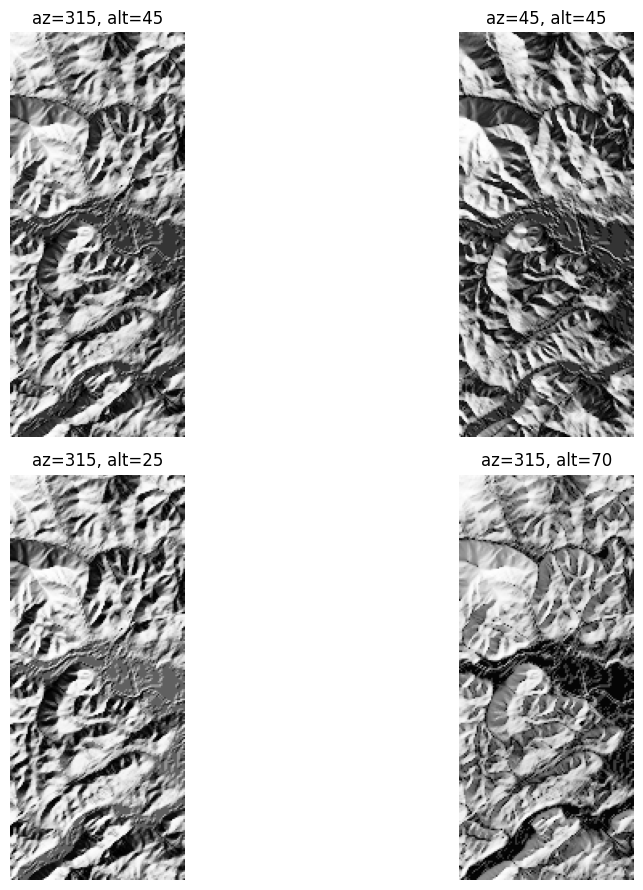

In [17]:
# Compare 4 lighting settings (small multiples)
settings = [(315, 45), (45, 45), (315, 25), (315, 70)]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
for ax, (az, alt) in zip(axes, settings):
    hs = es.hillshade(dem, azimuth=az, altitude=alt)
    ax.imshow(hs, cmap="Greys")
    ax.set_title(f"az={az}, alt={alt}")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

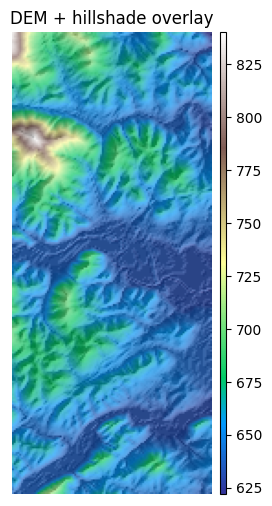

In [18]:
# 1) Plot the DEM as the base (color)
fig, ax = plt.subplots(figsize=(10, 6))
ep.plot_bands(
    dem,
    ax=ax,
    cmap="terrain",
    title="DEM + hillshade overlay",
    cbar=True,
)
# 2) Overlay hillshade (grayscale) with transparency
ax.imshow(hill, cmap="Greys", alpha=0.35) # try alpha: 0.2 -> 0.6
ax.set_axis_off()
plt.show()

In [19]:
# Save at high resolution for reports / portfolio
out_png = "outputs/dem_hillshade.png"
os.makedirs("outputs", exist_ok=True)
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print("Saved:", out_png)

Saved: outputs/dem_hillshade.png


In [20]:
# Write GeoTIFFs with rasterio (keeps CRS, transform, etc.)
os.makedirs("outputs", exist_ok=True)
def write_tif(path, arr, profile):
    prof = profile.copy()
    prof.update(dtype="float32", count=1, nodata=np.nan)
    with rio.open(path, "w", **prof) as dst:
        dst.write(arr.astype("float32"), 1)
write_tif("outputs/slope_degrees.tif", np.array(slope_deg), profile)
write_tif("outputs/aspect_degrees.tif", np.array(aspect), profile)
write_tif("outputs/hillshade.tif", hill.astype("float32"), profile)
print("Wrote GeoTIFFs to outputs/")

Wrote GeoTIFFs to outputs/


<b> 8. What is a DEM, and what does each pixel value represent? </b> <br>
-> <i> DEM is a digital representation of the bare earth surface, and each pixel value represents the elevation value of a specific location. <i> <br>
<b>  9. Why do we convert nodata values to np.nan before plotting? </b><br>
-> <i> We convert nodata values to np.nan before plotting so that extreme nodata values do not skew our color scale. <i> <br>
<b>  10. What does “resolution” mean for a raster, and how do you read it from the rasterio transform? </b><br>
-> <i> Resolution refers to the size of each pixel, and we read it from the raster transform function transform.a, and -transform.e <i> <br>
<b> 11. Which parameter changes the color ramp? Give two valid cmap names. </b><br>
-> <i> cmap parameter changes the color ramp. Example: "viridis" and "cividis" </i><br>
<b>  12. What do vmin and vmax do, and why might a percentile stretch be preferable to min/max? </b><br>
-> <i> vmin and vmax here define the minimum and maximum value used for colormap stretch. We prefer percentile stretch to min/max as sometimes the dataset might have extreme outliers. To mitigate the impact of those extreme outliers, we prefer percentile stretch. </i> <br> 
<b>  13. If you change the stretch, does it change the underlying data values? Why or why not? </b><br>
-> <i> No, changing the stretch does not change the underlying data values. The stretch only controls the values that have been mapped. </i> <br>
<b>  14. In one sentence: what does slope measure, and what does aspect measure? </b><br>
-> <i> Slope is the steepness calculated from elevation, and aspect estimates the direction a slope faces in degrees. </i><br>
<b>  15. Why is aspect considered a circular variable? </b><br>
-> <i> Aspect is considered a circular variable as it measures the slope direction in degrees clockwise from 0 degrees to 360 degrees. </i><br>
<b>  16. If your DEM is in degrees (lat/lon), what problem can that create for slope/aspect calculations? </b><br>
-> <i> If DEM is in degrees (lat/lon), it can introduce distortion during slope/aspect calculations, as DEM values in meters/feet and lat/lon in degrees are two different units that can cause distortion during the estimation process. </i><br>
<b>  17. What is the visual purpose of hillshade in cartography? </b><br>
-> <i> The visual purpose of hillshade in cartography is to provide depth perception to the map. </i><br>
<b>  18. Which parameter changes the direction of light? Which changes the sun height? </b><br>
-> <i> The azimuth parameter changes the direction of the light, and the altitude parameter changes the sun height.</i><br>
<b>  19. Why might you choose a lower altitude (more shadows) vs a higher altitude (flatter look)? </b><br>
-><i> A lower altitude (more shadows) can emphasize minor variation in relatively flat terrain, whereas a higher altitude (flatter look) prevents mountain or highly rugged terrain from being completely dark and unreadable. Based on the topography, we need to choose lower-altitude (flat terrain) and higher-altitude (mountainous terrain) areas. </i><br>
<b>  20. Which line controls the transparency of the hillshade overlay? </b><br>
-> <i> alpha parameter controls the transparency (ax.imshow(hill, cmap="Greys", alpha=0.35). </i><br>
<b>  21. If the overlay makes the map too dark, what two things can you adjust? </b><br>
-> <i> If the overlay makes the map too dark, we can change either the transparency (alpha) or increase the altitude to cast fewer shadows. </i><br>
<b>  22. Why is it helpful to keep a colorbar on the DEM even when adding hillshade? </b><br>
-><i> Keeping the colorbar on the DEM even when adding hillshade is helpful as it helps to quantify the differences between high and low areas. It added a quantitative meaning to the maps. <i><br>
